### **Download & Extract Dataset**

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip -O UCI_HAR_Dataset.zip
!unzip -q UCI_HAR_Dataset.zip

print("Dataset downloaded and extracted.")


--2025-12-15 21:18:14--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI_HAR_Dataset.zip’

UCI_HAR_Dataset.zip     [        <=>         ]  58.17M  35.1MB/s    in 1.7s    

2025-12-15 21:18:16 (35.1 MB/s) - ‘UCI_HAR_Dataset.zip’ saved [60999314]

Dataset downloaded and extracted.


### **Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


### **Load Raw Inertial Sensor Data**

In [ ]:
def load_inertial_signals(base_path, subset):
    signals = [
        "body_acc_x_", "body_acc_y_", "body_acc_z_",
        "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
        "total_acc_x_", "total_acc_y_", "total_acc_z_"
    ]

    data = []
    for signal in signals:
        file_path = f"{base_path}/{subset}/Inertial Signals/{signal}{subset}.txt"
        data.append(np.loadtxt(file_path))

    # Shape: (samples, 128, 9)
    return np.stack(data, axis=-1)

base_path = "/content/UCI HAR Dataset"

X_train = load_inertial_signals(base_path, "train")
X_test  = load_inertial_signals(base_path, "test")

y_train = np.loadtxt(f"{base_path}/train/y_train.txt").astype(int)
y_test  = np.loadtxt(f"{base_path}/test/y_test.txt").astype(int)
print(y_train)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(y_train.shape)


[5 5 5 ... 2 2 2]
Train shape: (7352, 128, 9)
Test shape: (2947, 128, 9)
(7352,)


### **Label Encoding & One-Hot Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # from 1..6 → 0..5
y_test_enc  = le.transform(y_test)

from tensorflow.keras.utils import to_categorical
import numpy as np

num_classes = len(np.unique(y_train_enc))
y_train_cat = to_categorical(y_train_enc, num_classes)
y_test_cat  = to_categorical(y_test_enc, num_classes)

print(y_train.shape)
print(y_train_cat.shape)


(7352,)
(7352, 6)


### **Scaling (Standardization)**

In [ ]:
scaler = StandardScaler()

# Reshape to 2D for scaling
n_samples, n_timesteps, n_features = X_train.shape

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled  = scaler.transform(X_test_2d)

# Reshape back to 3D
X_train = X_train_scaled.reshape(n_samples, n_timesteps, n_features)
X_test  = X_test_scaled.reshape(X_test.shape[0], n_timesteps, n_features)

print("Scaling completed.")


Scaling completed.


### **Build LSTM Model**

In [ ]:

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([

    LSTM(128, return_sequences=True, input_shape=(128, 9)),
    Dropout(0.5),

    LSTM(64),
    Dropout(0.5),

    Dense(6, activation="softmax")
])


optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


callbacks = [

    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),


    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]



model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,454 (470.52 KB)

 Trainable params: 120,454 (470.52 KB)

 Non-trainable params: 0 (0.00 B)

### **Train the Model**

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 337ms/step - accuracy: 0.4557 - loss: 1.3305 - val_accuracy: 0.8892 - val_loss: 0.4091 - learning_rate: 5.0000e-04
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 326ms/step - accuracy: 0.9093 - loss: 0.3257 - val_accuracy: 0.8953 - val_loss: 0.3117 - learning_rate: 5.0000e-04
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 331ms/step - accuracy: 0.9425 - loss: 0.2077 - val_accuracy: 0.9075 - val_loss: 0.2911 - learning_rate: 5.0000e-04
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 334ms/step - accuracy: 0.9490 - loss: 0.1788 - val_accuracy: 0.8994 - val_loss: 0.3053 - learning_rate: 5.0000e-04
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 321ms/step - accuracy: 0.9455 - loss: 0.1555 - val_accuracy: 0.8885 - val_loss: 0.3296 - learning_rate: 5.0000e-04
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 334ms/step - accuracy: 0.9579 - loss: 0.1500 - val_accuracy: 0.9001 - val_loss: 0.2450 - learning_rate: 5.0000e-04
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 321ms/step - acc

In [ ]:
model.save('activity_model.keras')
print("Model saved as activity_model.keras")

Model saved as activity_model.keras


### **Model Evaluation (Accuracy, Loss, Precision)**

In [ ]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Metrics
test_accuracy = accuracy_score(y_test_enc, y_pred)
test_precision = precision_score(y_test_enc, y_pred, average="weighted")

test_loss, _ = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Loss      : {test_loss:.4f}")


93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step
Test Accuracy  : 0.9074
Test Precision : 0.9080
Test Loss      : 0.3258


### **Plot Training vs Validation Loss (Complexity Curve)**

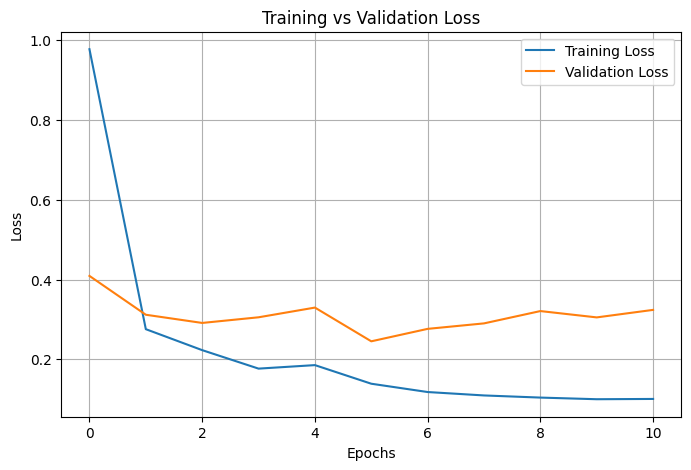

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


### **Plot Training vs Validation Accuracy**

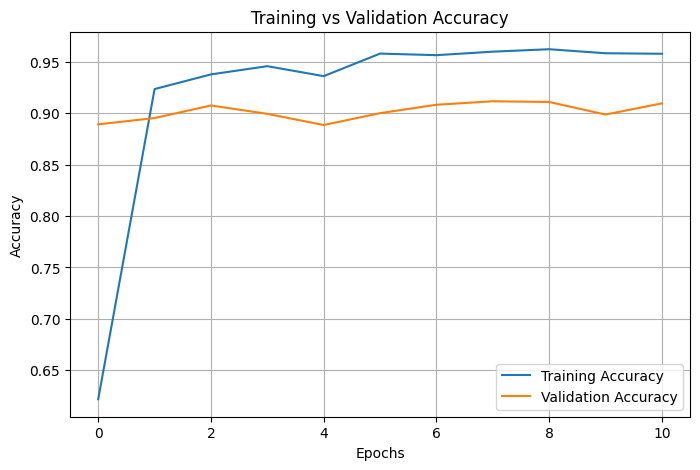

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Install dependencies
!pip install streamlit pyngrok transformers torch datasets --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 114.6 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok, conf

NGROK_AUTH_TOKEN = "32Qdpgmy9sPSiz0aY5DxD6YwSg8_4GHmT26Dud9dXqPXR35rD"

!ngrok config add-authtoken $NGROK_AUTH_TOKEN

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!kill -9 $(pgrep ngrok)

kill: usage: kill [-s sigspec | -n signum | -sigspec] pid | jobspec ... or kill -l [sigspec]


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import tensorflow as tf
import time

# 1. Load the Model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('activity_model.keras')
    return model

try:
    model = load_model()
    st.success("Model loaded successfully!")
except:
    st.error("Model not found. Please ensure 'activity_model.keras' is in the current directory.")

# 2. Define Classes (Update these based on your specific dataset labels)
CLASSES = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']

st.title("🏃 Activity Recognition Dashboard")
st.write("Predicting human activity based on sensor data.")

# 3. Sidebar for Input Selection
st.sidebar.header("Input Options")
input_mode = st.sidebar.radio("Choose Input Mode:", ["Manual Sliders", "Upload CSV", "Simulated Stream"])

# --- MODE 1: MANUAL SLIDERS ---
if input_mode == "Manual Sliders":
    st.header("Manual Feature Input")
    st.info("Adjust sliders to simulate a constant sensor reading over the 128 time steps.")

    # Create 9 sliders for the 9 features
    features = []
    col1, col2, col3 = st.columns(3)

    with col1:
        fx = st.slider("Acc X", -2.0, 2.0, 0.0)
        fy = st.slider("Acc Y", -2.0, 2.0, 0.0)
        fz = st.slider("Acc Z", -2.0, 2.0, 0.0)
    with col2:
        gx = st.slider("Gyro X", -2.0, 2.0, 0.0)
        gy = st.slider("Gyro Y", -2.0, 2.0, 0.0)
        gz = st.slider("Gyro Z", -2.0, 2.0, 0.0)
    with col3:
        tx = st.slider("Total Acc X", -2.0, 2.0, 0.0)
        ty = st.slider("Total Acc Y", -2.0, 2.0, 0.0)
        tz = st.slider("Total Acc Z", -2.0, 2.0, 0.0)

    # Create the sequence: Shape (1, 128, 9)
    # We repeat the slider values 128 times to simulate a stable activity
    single_step = [fx, fy, fz, gx, gy, gz, tx, ty, tz]
    sequence = np.tile(single_step, (128, 1)).reshape(1, 128, 9)

    if st.button("Predict Activity"):
        prediction = model.predict(sequence)
        class_idx = np.argmax(prediction)
        confidence = np.max(prediction)

        st.metric(label="Predicted Activity", value=CLASSES[class_idx])
        st.progress(float(confidence))
        st.write(f"Confidence: {confidence:.2%}")

# --- MODE 2: UPLOAD CSV ---
elif input_mode == "Upload CSV":
    st.header("Batch Prediction from CSV")
    uploaded_file = st.file_uploader("Upload CSV (must have 9 columns)", type="csv")

    if uploaded_file is not None:
        data = pd.read_csv(uploaded_file)
        st.write("Data Preview:", data.head())

        # Check if we have enough data for at least one sequence (128 steps)
        if len(data) >= 128:
            if st.button("Process & Predict"):
                # Take the first 128 rows for demonstration
                sequence = data.iloc[:128, :9].values.reshape(1, 128, 9)

                prediction = model.predict(sequence)
                class_idx = np.argmax(prediction)
                confidence = np.max(prediction)

                st.success(f"Prediction based on first 128 rows: **{CLASSES[class_idx]}**")
                st.bar_chart(pd.DataFrame(prediction.T, index=CLASSES, columns=["Probability"]))
        else:
            st.warning("CSV must have at least 128 rows to form one sequence.")

# --- MODE 3: SIMULATED STREAM ---
elif input_mode == "Simulated Stream":
    st.header("Real-Time Simulated Sensor Data")
    placeholder = st.empty()
    stop_button = st.button("Stop Simulation")

    while not stop_button:
        # Generate random noise to simulate active sensor data
        # Shape (1, 128, 9)
        fake_data = np.random.normal(0, 1, size=(1, 128, 9))

        prediction = model.predict(fake_data, verbose=0)
        class_idx = np.argmax(prediction)
        confidence = np.max(prediction)

        with placeholder.container():
            col1, col2 = st.columns(2)
            with col1:
                st.metric(label="Live Prediction", value=CLASSES[class_idx])
            with col2:
                st.metric(label="Confidence", value=f"{confidence:.2%}")

            # Simple chart of the "sensor" input
            st.line_chart(fake_data[0, :, 0]) # Plotting 1st feature over time

        time.sleep(1) # Update every second

Writing app.py


In [ ]:
!pkill streamlit
!pkill ngrok

!streamlit run app.py &>/dev/null &
from pyngrok import ngrok
url = ngrok.connect(8501)
print("Chatbot running at:", url)

Chatbot running at: NgrokTunnel: "https://0576ed77bea9.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
import os

# 2. Run Streamlit in the background
os.system("streamlit run app.py &")

# 3. Create the tunnel
public_url = ngrok.connect(8501).public_url
print(f"🚀 Streamlit is active at: {public_url}")

🚀 Streamlit is active at: https://635c327a267f.ngrok-free.app
